<a href="https://colab.research.google.com/github/AdepoEO/Plant-Seedling-Classification/blob/main/Plants_Seedling_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plant Seedling Classification using CNN**

 I will build a Convolutional Neural Network (CNN) to classify plant seedlings into one of 12 unique species. The datasets are from the Signal Processing group at Aarhus University in collaboration with the University of Southern Denmark.


##**Data Overview**

The dataset contains images of seedlings from 12 different plant species. Due to the large size of the image data, images have been converted into numpy arrays and stored in images.npy. Corresponding labels are provided in Labels.csv.


*   images.npy: Numpy array of seedling images
*   Labels.csv: CSV file with species lables for each image



##**Objective**

Create an accurate CNN-based classifier that identifies the species of a plant seedling based on its image.



###**List of Plant Species**

*   Black-grass
*   Charlock
*   Cleavers
*   Common Checkweed
*   Fat Hen
*   Loose Silky-bent
*   Maize
*   Scentless Mayweed
*   Shepherds Purse
*   Small-flowered Cranesbill
*   Sugar beet





###**Importing necessary libraries**

In [ ]:
# Installing libraries with the specified version
!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==2.0.3 opencv-python==4.8.0.76 -q --user


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [ ]:
import os
import numpy as np                                                                                      # Importing numpy for Matrix Operations
import pandas as pd                                                                                     # Importing pandas to read CSV files
import seaborn as sns                                                                                # Importing seaborn to plot graphs
import matplotlib.pyplot as plt                                                                         # Importing matplotlib for Plotting and visualizing images
import math                                                                                             # Importing math module to perform mathematical operations
import cv2                                                                                              # Importing openCV for image processing

# Tensorflow modules
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                                     # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                          # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization   # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam, SGD                                                       # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                       # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                                    # Importing train_test_split function to split the data into train and test sets
from sklearn.metrics import confusion_matrix                                                            # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelBinarizer

# Display images using OpenCV
from google.colab.patches import cv2_imshow                                                             # Importing cv2_imshow from google.patches to display images
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend
from keras.callbacks import ReduceLROnPlateau
import random

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

###**Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load the image file of the dataset
images = np.load('/content/drive/MyDrive/AIML/Computer Vision/images.npy')

# load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/AIML/Computer Vision/Labels.csv')

###**Data Overview**

####**Understand the shape of the dataset**

In [ ]:
print(images.shape)
print(labels.shape)

(4750, 128, 128, 3)
(4750, 1)


##**Exploratory Data Analysis**

####**Plotting random images from each of the classes**

In [ ]:
def plot_images(images,labels):
  num_classes=10                                                                # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                    # Obtaining the unique classes from y_train
  rows = 3                                                                      # Defining number of rows = 3
  cols = 4                                                                      # Defining number of columns = 4
  fig = plt.figure(figsize=(10, 8))                                             # Defining the figure size to 10x8
  for i in range(cols):
    for j in range(rows):
      random_index = np.random.randint(0, len(labels))                          # Generating random indices from the data and plotting the images
      ax = fig.add_subplot(rows, cols, i * rows + j + 1)                        # Adding subplots with 3 rows and 4 columns
      ax.imshow(images[random_index, :])                                        # Plotting the image
      ax.set_title(keys[random_index])
  plt.show()


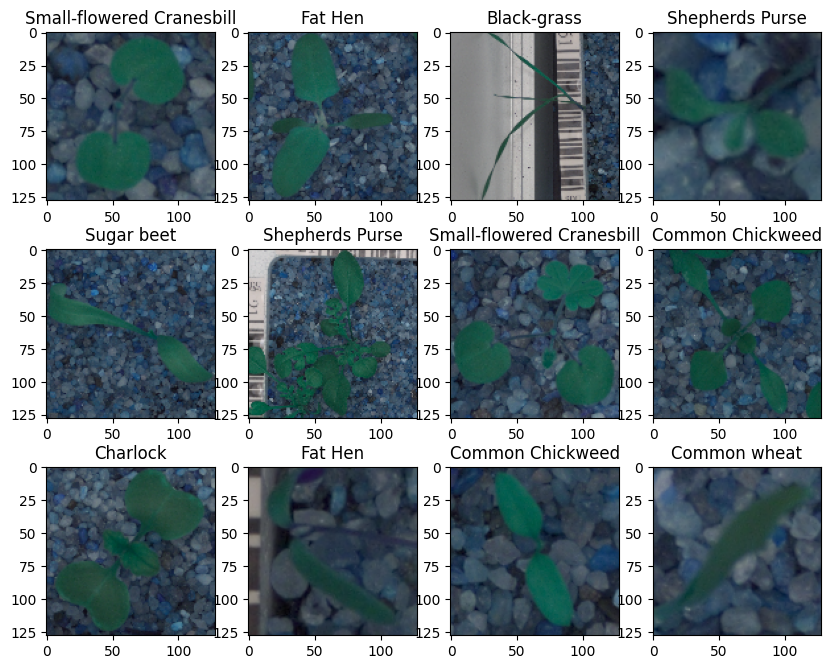

In [ ]:
plot_images(images,labels)                                                               # Complete the code to input the images and labels to the function and plot the images with their labels

**Checking for data imbalance**

(array([  0., 100., 200., 300., 400., 500., 600., 700.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

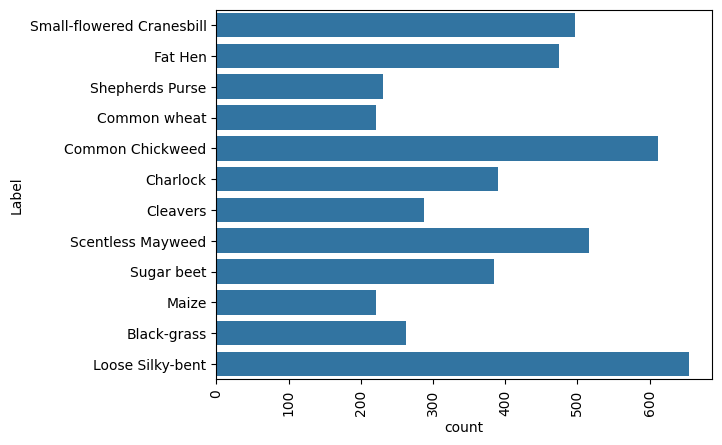

In [ ]:
sns.countplot(labels['Label'])
plt.xticks(rotation=90)

- The above plot reveals that the dataset is not balanced
- There are varied number of images in each category

##**Data Pre-Processing**

####**Convert the BGR images to RGB images**

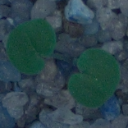

In [ ]:
cv2_imshow(images[9])

- The same images looks different when plotted with OpenCV compared to Matplotlib, because OpenCV reads images in BGR format. BGR format shows that the given numpy arrays were generated from the original images using OpenCV
- We need to convert the BGR images to RGB images to interpret them easily and correctly

In [ ]:
# Converting the images from BGR to RGB using cvtColor function from OpenCV

for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

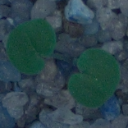

In [ ]:
cv2_imshow(images[9])

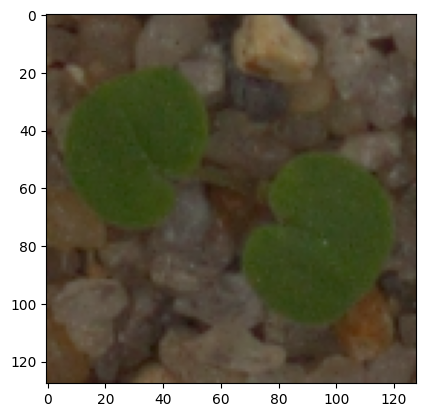

In [ ]:
plt.imshow(images[9]);

**Resize the images**

- Reduce the image size from 128 to 64, because it is computationally expensive to train on larger images

In [ ]:
images_decreased=[]
height = 64
width = 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append(cv2.resize(images[i], dimensions))

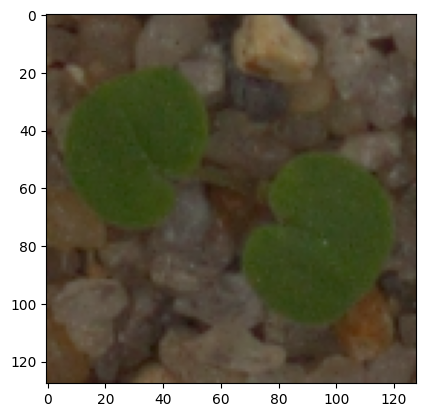

In [ ]:
plt.imshow(images[9])

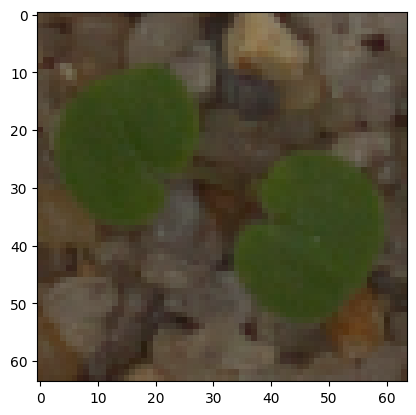

In [ ]:
plt.imshow(images_decreased[9])

###**Visualizing images using Gaussian Blur**

In [ ]:
# Applying Gaussian Blur to denoise the images
images_gb=[]
for i in range(len(images_decreased)):
  images_gb.append(cv2.GaussianBlur(images_decreased[i], ksize=(3,3), sigmaX=0))

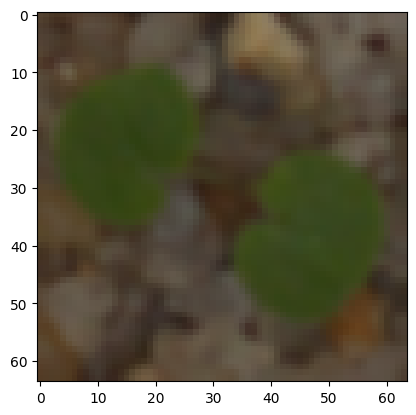

In [ ]:
plt.imshow(images_gb[9])

- GaussianBlur is not helpful because the image is still blurred, and the model would struggle to categorize blurred images

##**Data Preparation for Modeling**

- Split the data into train, test and validation to evaluate the model built on train data
- Encode categorical features and scale the pixel values
- Build a model using the train data and then check its performance


**Split the dataset**

- Use 10% of the data for testing, 10% for validation and 80% for training
- Use the train_test_split() function from scikit-learn

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(np.array(images_decreased),labels, test_size=0.1, random_state=1, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, random_state=1, stratify=y_temp)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(3847, 64, 64, 3) (3847, 1)
(428, 64, 64, 3) (428, 1)
(475, 64, 64, 3) (475, 1)


In [ ]:
# treat class imbalance by increasing the weights of the minority classes

from sklearn.utils import class_weight

labelList = labels.Label.unique()
class_weights = class_weight.compute_class_weight(class_weight = "balanced",
                                                  classes = np.array(labelList),
                                                  y = y_train.values.reshape(-1)
                                                  )
class_weights_dict = dict(zip(np.array(range(len(labelList))), class_weights))

#print calculated class weights
class_weights_dict

{np.int64(0): np.float64(0.7974709784411277),
 np.int64(1): np.float64(0.8348524305555556),
 np.int64(2): np.float64(1.714349376114082),
 np.int64(3): np.float64(1.7909683426443204),
 np.int64(4): np.float64(0.6476430976430977),
 np.int64(5): np.float64(1.0145042194092826),
 np.int64(6): np.float64(1.3818247126436782),
 np.int64(7): np.float64(0.7669457735247209),
 np.int64(8): np.float64(1.0275106837606838),
 np.int64(9): np.float64(1.7909683426443204),
 np.int64(10): np.float64(1.5050860719874803),
 np.int64(11): np.float64(0.604874213836478)}

In [ ]:
np.array(range(len(labelList)))
dict(zip(np.array(range(len(labelList))), class_weights))
class_weights

array([0.79747098, 0.83485243, 1.71434938, 1.79096834, 0.6476431 ,
       1.01450422, 1.38182471, 0.76694577, 1.02751068, 1.79096834,
       1.50508607, 0.60487421])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11')])

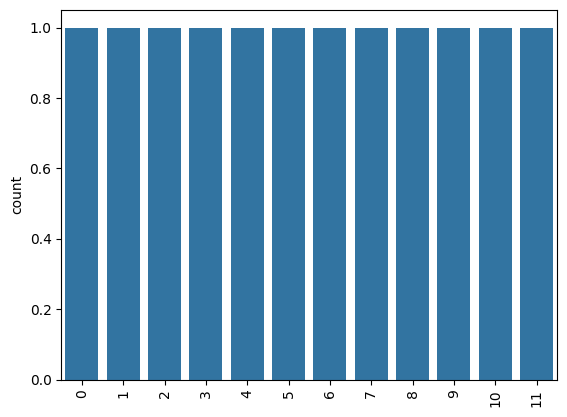

In [ ]:
sns.countplot(class_weights)
plt.xticks(rotation=90)

(array([  0., 100., 200., 300., 400., 500., 600., 700.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700')])

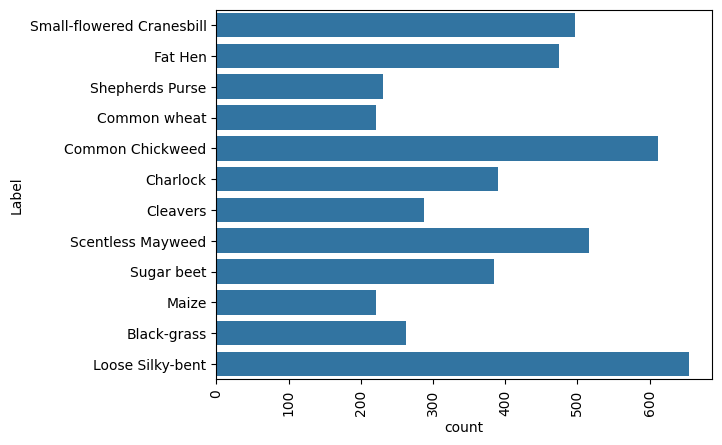

In [ ]:
sns.countplot(labels['Label'])
plt.xticks(rotation=90)

###**Make the data compatible**

- Convert the labels from names to one hot vectors
- Normalize the values

###**Encode the target labels**

In [ ]:
# Convert the labels from names to one hot vectors
# We've used encoding methods like onehotencoder and labelencoder before.

# This time we'll use Labelbinarizer - a technique to encode the target variables which reduces
## the sparsity as compared to one hot encoder.

from sklearn.preprocessing import LabelBinarizer

# Storing the LabelBinarizer function in enc variable
enc = LabelBinarizer()

# Applying fit_transform on train target variable
y_train_encoded = enc.fit_transform(y_train)

# Applying fit_transform on validation target variable
y_val_encoded = enc.fit_transform(y_val)

# Applying fit_transform on test target variable
y_test_encoded = enc.fit_transform(y_test)

In [ ]:
y_train_encoded.shape, y_val_encoded.shape, y_test_encoded.shape

((3847, 12), (428, 12), (475, 12))

###**Data Normalization**

- Since the image pixel values range from 0-255, my method of normalization here will be scaling.
- I will divide the pixel values by 255 to standardize the images to have values between 0-1

In [ ]:
# Normalizing the image pixels for the train, test and validation data

X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

##**Model Building - Convolutional Neural Network (CNN)**

I will create a CNN model sequentially, where I will be adding the layers one after another.

- First, I clear the previous model's history from the session even if a single model can run multiple times on the same data.
- In Keras, I use backend.clear_session(), otherwise the previous model history remains in the backend
- Fix the seed again after clearing the backend by setting the seed for random number generators in Numpy, the Random library in Python, and in Tensorflow, to be able to reproduce the same results every time we run the code

In [ ]:
# clear the backend
backend.clear_session()

In [ ]:
# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

Build a CNN model with the following 2 main parts:
1. The **Feature Extraction layers**, which comprise the convolutional and pooling layers
2. The **Fully Connected classification layers** for prediction


In [ ]:
 # Initializing a sequential model
 model1 = Sequential()

# Adding first convolutional layer with 64 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of images
model1.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))

# Adding max pooling to reduce the output size of the first convolutional layer
model1.add(MaxPooling2D((2, 2), padding='same'))

model1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D((2, 2), padding='same'))

model1.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D((2, 2), padding='same'))

# flattening the output of the convolutional layer after max pooling to make it ready for creating dense connections
model1.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model1.add(Dense(16, activation='relu'))
model1.add(Dropout(0.3))

# Adding the output layer with 12 neurons and activation function as softmax since this is a multi-class classification
model1.add(Dense(12, activation='softmax'))

# Using Adam Optimizer
opt = Adam()

# Compile the model using the categorical_crossentropy loss function and accuracy metric
model1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,172 (352.23 KB)

 Trainable params: 90,172 (352.23 KB)

 Non-trainable params: 0 (0.00 B)

- The model will train and learn **90,172 parameters (weights/biases)**

###**Fitting the model on the train data**

In [ ]:
history_1 = model1.fit(
    X_train_normalized, y_train_encoded,
    epochs = 30,
    validation_data=(X_val_normalized, y_val_encoded),
    batch_size=32
)

Epoch 1/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 75s 605ms/step - accuracy: 0.0962 - loss: 2.4642 - val_accuracy: 0.2360 - val_loss: 2.3292
Epoch 2/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 59s 493ms/step - accuracy: 0.1912 - loss: 2.2785 - val_accuracy: 0.3364 - val_loss: 1.8965
Epoch 3/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 407ms/step - accuracy: 0.2937 - loss: 2.0097 - val_accuracy: 0.3411 - val_loss: 1.7701
Epoch 4/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 402ms/step - accuracy: 0.3164 - loss: 1.8654 - val_accuracy: 0.3738 - val_loss: 1.7421
Epoch 5/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 50s 417ms/step - accuracy: 0.3152 - loss: 1.8340 - val_accuracy: 0.4159 - val_loss: 1.6235
Epoch 6/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 49s 406ms/step - accuracy: 0.3407 - loss: 1.7652 - val_accuracy: 0.5023 - val_loss: 1.5832
Epoch 7/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 52s 433ms/step - accuracy: 0.3580 - loss: 1.7159 - val_accuracy: 0.5327 - val_loss: 1.5260
Epoch 8/30
121/121 ━━━━━━━━━━━━━━━━━━━━ 52s 430ms/step - accuracy: 0.3756 - loss: 1

**Model Evaluation**

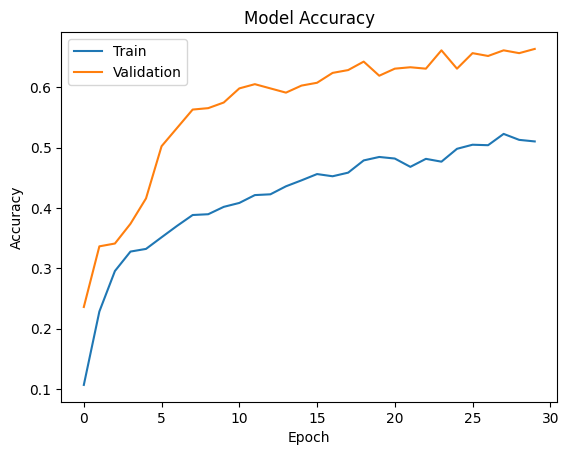

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Observations:**
- From the above plot, the model is overfitting based on the diverging distances between the Train and Validation graphs

**Evaluate the model on test data**

In [ ]:
accuracy = model1.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 91ms/step - accuracy: 0.6253 - loss: 1.1096


- The model's accuracy is 59%

**Plotting the Confusion Matrix**

In [ ]:
y_pred=model1.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step


- The Confusion Matrix is also defined as an inbuilt function in the TensorFlow module, so I can use that for evaluating the classification model
- The Confusion Matrix expects categorical data as input. However, y_test_encoded is an encoded value, whereas y_pred has probabilities.
- I must retrieve the categorical values from the encoded values.
- I will use the `argmax()` function to obtain the maxiumum value over each category on both y_test_encoded and y_pred, and obtain their respective classes.

In [ ]:
enc.classes_

array(['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed',
       'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize',
       'Scentless Mayweed', 'Shepherds Purse',
       'Small-flowered Cranesbill', 'Sugar beet'], dtype='<U25')

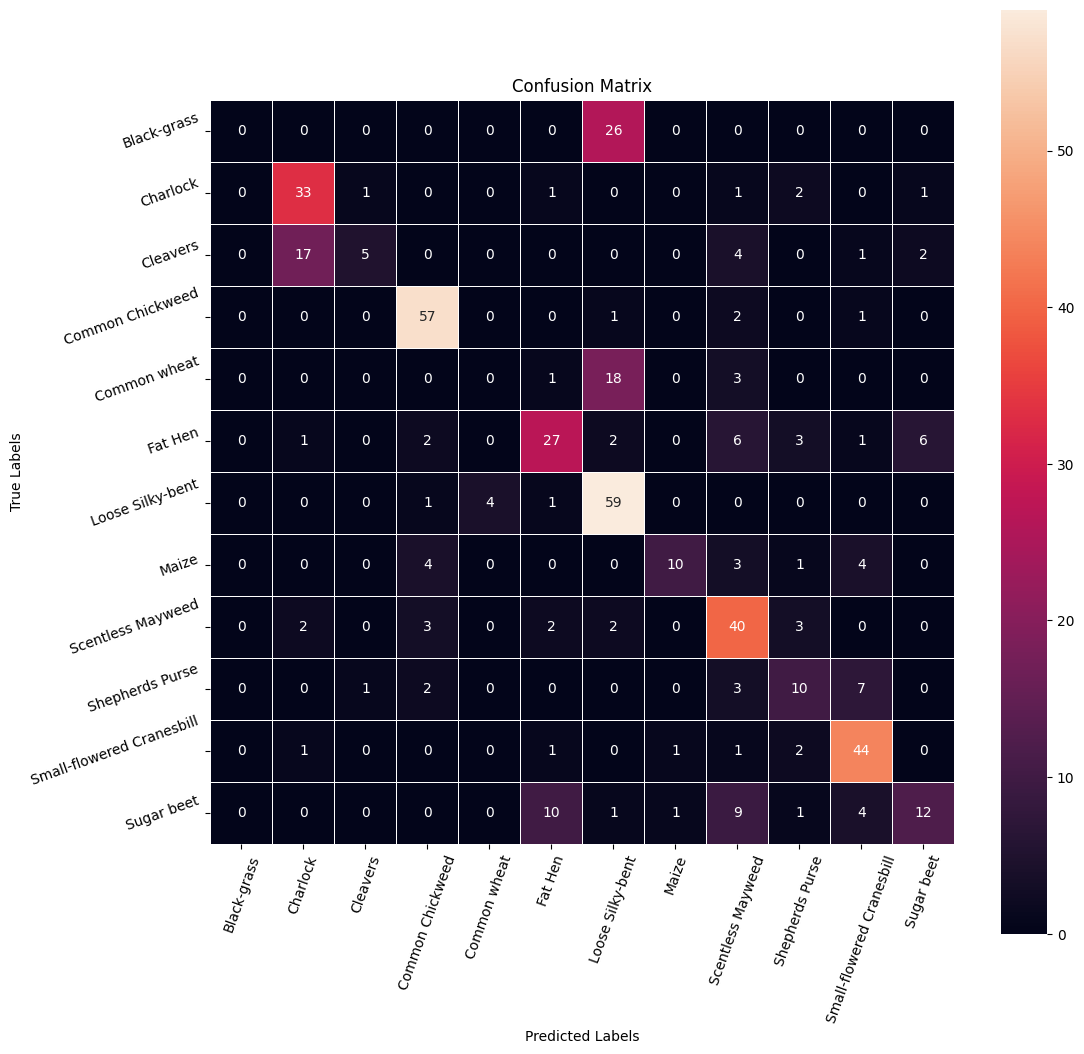

In [ ]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred, axis=1)
y_test_arg=np.argmax(y_test_encoded, axis=1)

# Plotting the Confusion Matrix using confusion_matrix() function which is also predefined in the Tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg )
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt='d',
    square=True,
    ax=ax
)

# Setting the labels to both the axes
ax.set_xlabel('Predicted Labels');ax.set_ylabel('True Labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=70)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

**Observations:**
- Some of the classes are not predicted correctly
- The classes '_Loose Silky-bent_','_Common Chickweed_' and '_Small-flowered Cranesbill_' are best classified
- The most misclassified classes are '_Black grass_', '_Common Wheat_' and '_Maize_'

**Plotting the Classification Report**

In [ ]:
# Plot the classification report

from sklearn.metrics import classification_report

cr = classification_report(y_test_arg, y_pred_arg )
print(cr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.61      0.85      0.71        39
           2       0.71      0.17      0.28        29
           3       0.83      0.93      0.88        61
           4       0.00      0.00      0.00        22
           5       0.63      0.56      0.59        48
           6       0.54      0.91      0.68        65
           7       0.83      0.45      0.59        22
           8       0.56      0.77      0.65        52
           9       0.45      0.43      0.44        23
          10       0.71      0.88      0.79        50
          11       0.57      0.32      0.41        38

    accuracy                           0.63       475
   macro avg       0.54      0.52      0.50       475
weighted avg       0.58      0.63      0.58       475



##**Model Performance Improvement**

###**Model 2 _ Data Augmentation**

**Reducing the Learning Rate:**

**ReduceLRonPlateau()** is a function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [ ]:
# Monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

###**Data Augmentation**

In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs. To overcome this problem, one approach I considered is **Data Augmentation.** CNNs have the property of **translational invariance**, which means they can recognize an object even if its appearance shifts translationally in some way.

Taking this attribute into account, I can augment the images using the techniques listed below:
1. **Horizontal Flip** (should be set to True/False)
2. **Vertical Flip** (should be set to True/False)
3. **Height Shift** (should be between 0 and 1)
4. **Width Shift** (should be between 0 and 1)
5. **Rotation** (should be between 0 and 180)
6. **Shear** (should be between 0 and 1)
7. **Zoom** (should be between 0 and 1)

- **Data Augmentation is not be used in the validation/test data set**

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set the rotation range to 20

train_datagen = ImageDataGenerator(
                                rotation_range=20,
                                fill_mode='nearest'
                                  )

In [ ]:
# Initialize a sequential model
model2 = Sequential()

# Adding first convolutional layer with 64 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of images
model2.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))

# Adding max pooling to reduce the output size of the first convolutional layer
model2.add(MaxPooling2D((2, 2), padding='same'))

model2.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model2.add(MaxPooling2D((2, 2), padding='same'))
model2.add(BatchNormalization())

# model2.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# model2.add(MaxPooling2D((2, 2), padding='same'))

# flattening the output of the convolutional layer after max pooling to make it ready for creating dense connections
model2.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model2.add(Dense(16, activation='relu'))
model2.add(Dropout(0.3))

# Adding the output layer with 12 neurons and activation function as softmax since this is a multi-class classification
model2.add(Dense(12, activation='softmax'))

# Using Adam Optimizer
opt = Adam()

# Compile the model using the categorical_crossentropy loss function and accuracy metric
model2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model2.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       262,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,340 (1.15 MB)

 Trainable params: 301,212 (1.15 MB)

 Non-trainable params: 128 (512.00 B)

- This CNN model will train and learn **301,212 parameters (weights and biases)**.

**Fitting the model on train data**

In [ ]:
# Fit the model on train data with batch_size = 64 and epochs=30
#Epochs
epochs = 30
#Batch size
batch_size = 64


history = model2.fit(train_datagen.flow(
    X_train_normalized, y_train_encoded,
    batch_size=batch_size,
    shuffle=False),
    epochs = epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_encoded),
    verbose=1,
    callbacks=[learning_rate_reduction]
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 57s 882ms/step - accuracy: 0.1648 - loss: 2.4021 - val_accuracy: 0.1846 - val_loss: 2.3854 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3125 - loss: 2.1990 - val_accuracy: 0.1822 - val_loss: 2.3871 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 908ms/step - accuracy: 0.3846 - loss: 1.9019 - val_accuracy: 0.3201 - val_loss: 2.3570 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3281 - loss: 2.0791 - val_accuracy: 0.2850 - val_loss: 2.3712 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 78s 867ms/step - accuracy: 0.4302 - loss: 1.6974 - val_accuracy: 0.3014 - val_loss: 2.2712 - learning_rate: 0.0010
Epoch 6/30
 1/60 ━━━━━━━━━━━━━━━━━━━━ 1:07 1s/step - accuracy: 0.4219 - loss: 1.6703
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4219 - loss: 1.6703 - va

**Model Evaluation**

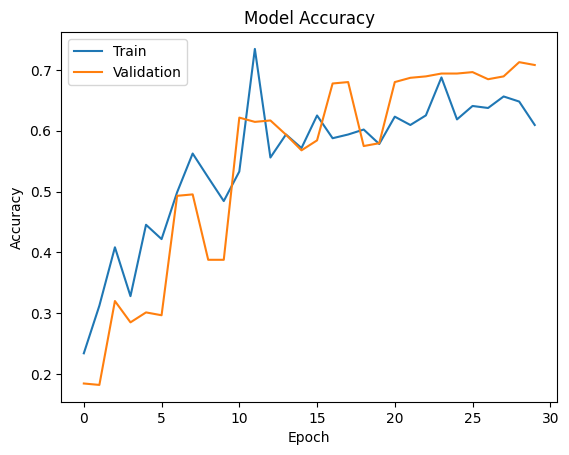

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- The model achieves better accuracy peformance as revealed by the closeness of the Train and Validation graphs

**Evaluate the model on test data**

In [ ]:
accuracy = model2.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 79ms/step - accuracy: 0.6674 - loss: 0.9915


- The model's accuracy performance has improved; from 59% now to 76%

**Plotting the Confusion Matrix**

In [ ]:
y_pred=model2.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step


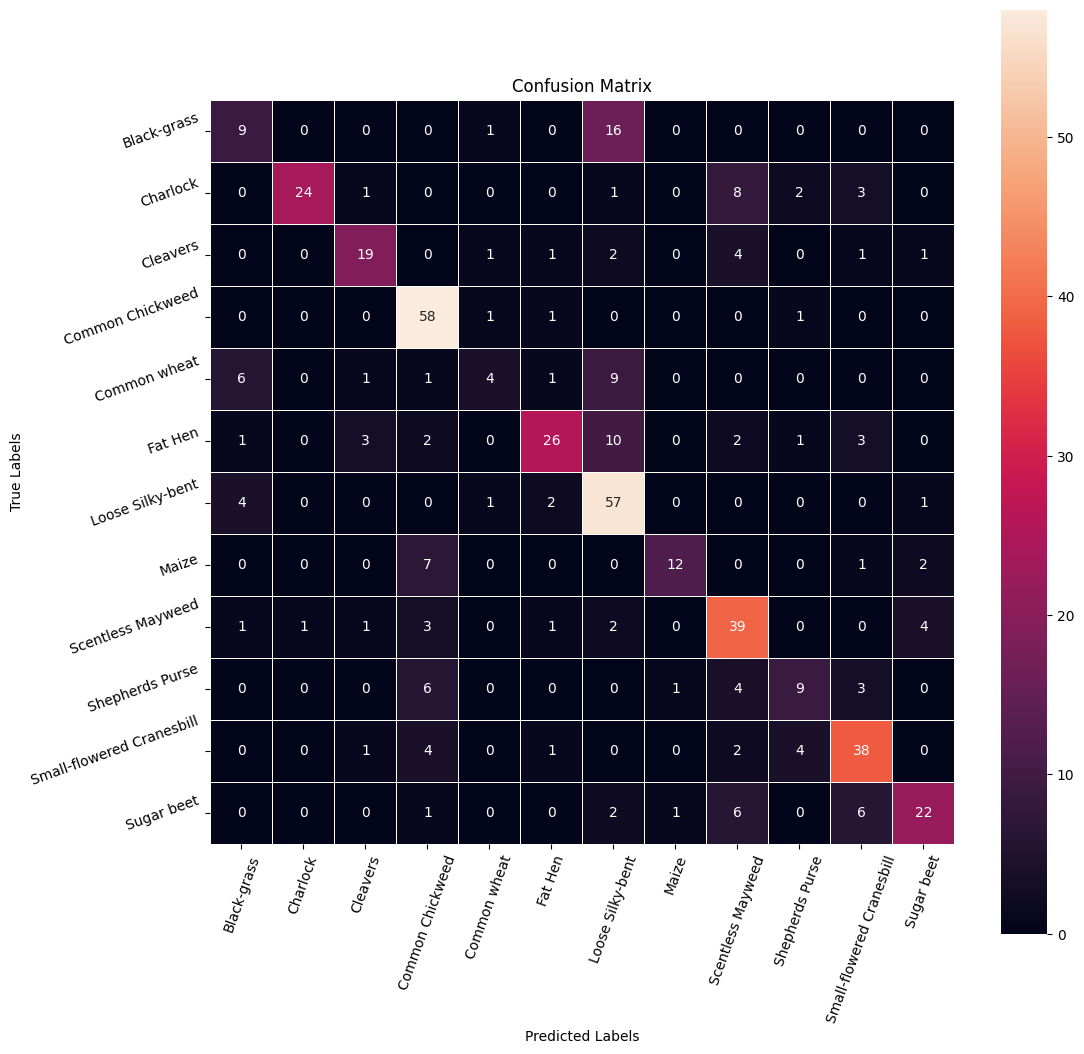

In [ ]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred, axis=1)
y_test_arg=np.argmax(y_test_encoded, axis=1)

# Plotting the Confusion Matrix using confusion_matrix() function which is also predefined in the Tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg )
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt='d',
    square=True,
    ax=ax
)

# Setting the labels to both the axes
ax.set_xlabel('Predicted Labels');ax.set_ylabel('True Labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=70)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

**Observations:**
- Some of the classes are not predicted correctly
- The 4 best classified classes '_Loose Silky-bent_','_Common Chickweed_', '_Scentless Mayweed_' and '_Small-flowered Cranesbill_'
- The 4 most misclassified classes are '_Black grass_', '_Common Wheat_', '_Shepherds Purse_' and '_Maize_'

**Plotting the Classification Report**

In [ ]:
# Plot the classification report
cr= classification_report(y_test_arg, y_pred_arg )
print(cr)

              precision    recall  f1-score   support

           0       0.43      0.35      0.38        26
           1       0.96      0.62      0.75        39
           2       0.73      0.66      0.69        29
           3       0.71      0.95      0.81        61
           4       0.50      0.18      0.27        22
           5       0.79      0.54      0.64        48
           6       0.58      0.88      0.70        65
           7       0.86      0.55      0.67        22
           8       0.60      0.75      0.67        52
           9       0.53      0.39      0.45        23
          10       0.69      0.76      0.72        50
          11       0.73      0.58      0.65        38

    accuracy                           0.67       475
   macro avg       0.68      0.60      0.62       475
weighted avg       0.68      0.67      0.65       475



##**Model 3**

### Transfer Learning (VGG16) with Data Augmentation

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set the rotation range to 20

train_datagen = ImageDataGenerator(
                                rotation_range=20,
                                fill_mode='nearest'
                                  )

- Build the model using the idea of Transfer Learning with Data Augmentation by loading a pre-built architecture - VGG16, which was trained on the ImageNet dataset and finished runner-up in the ImageNet competition in 2014.
- To train VGG16, I will use the convoutional and pooling layers and freeze their weights, i.e., no training on them. Remove the already-present fully-connected layers and add my own fully-connected layers for this multi-class classification task.

In [ ]:
# importing the VGG16 model
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

# Loading VGG16 model
model = VGG16(weights='imagenet')

#Summary of the whole model
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Getting only the convolutional layers for transfer learning
transfer_layer = model.get_layer('block5_pool')
vgg_model = Model(inputs=model.input, outputs=transfer_layer.output)

In [ ]:
vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

- When I import a pre-trained model from Keras, I can remove the fully-connected (top) layers by setting the keyword argument, **include_top=False**.

- By specifying **include_top=False**, the model is imported without its original fully-connected layers, so I don’t have to manually get the last convolutional layer or create a separate model.

- If I use **include_top=False**, I need to specify the input image shape with the input_shape argument because the default input size is linked to the full model including the top layers.

- I use this option often in transfer learning, where I keep the pretrained convolutional base and add my own fully-connected layers for the specific task I’m working on.

In [ ]:
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape = (64, 64, 3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Making all the layers of the VGG16 Model non-trainable, i.e., freezing them
for layer in vgg_model.layers:
  layer.trainable = False

In [ ]:
for layer in vgg_model.layers:
  print(layer.name, layer.trainable)

input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 False
block5_conv2 False
block5_conv3 False
block5_pool False


In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Initializing the model
model3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model3.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model3.add(Dense(16, activation='relu'))
model3.add(Dropout(0.3))

# Adding the output layer with 12 neurons and activation function as softmax since this is a multi-class classification
model3.add(Dense(12, activation='softmax'))

# Using Adam Optimizer
opt = Adam()

# Compile the model using the categorical_crossentropy loss function and accuracy metric
model3.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,676 (56.26 MB)

 Trainable params: 32,988 (128.86 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

- The CNN moddel will train and learn **32,988 parameters (weights and biases)**.

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Fit the model on train data with batch_size = 64 and epochs=30
#Epochs
epochs = 30
#Batch size
batch_size = 64


history_vgg16 = model3.fit(train_datagen.flow(
    X_train_normalized, y_train_encoded,
    batch_size=batch_size,
    shuffle=False),
    epochs = epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_encoded),
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 245s 4s/step - accuracy: 0.1065 - loss: 2.4648 - val_accuracy: 0.1939 - val_loss: 2.3233
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 695ms/step - accuracy: 0.1094 - loss: 2.3261 - val_accuracy: 0.1986 - val_loss: 2.3213
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.1772 - loss: 2.3329 - val_accuracy: 0.2874 - val_loss: 2.2135
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 46s 695ms/step - accuracy: 0.2812 - loss: 2.2347 - val_accuracy: 0.2967 - val_loss: 2.2090
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.2538 - loss: 2.2313 - val_accuracy: 0.3084 - val_loss: 2.1259
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 375ms/step - accuracy: 0.2500 - loss: 2.2560 - val_accuracy: 0.3294 - val_loss: 2.1230
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.2813 - loss: 2.1709 - val_accuracy: 0.3785 - val_loss: 1.9968
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 365ms/step - accuracy: 0.2812 - loss: 2.2305 - val_accuracy: 0.

**Model Evaluation**

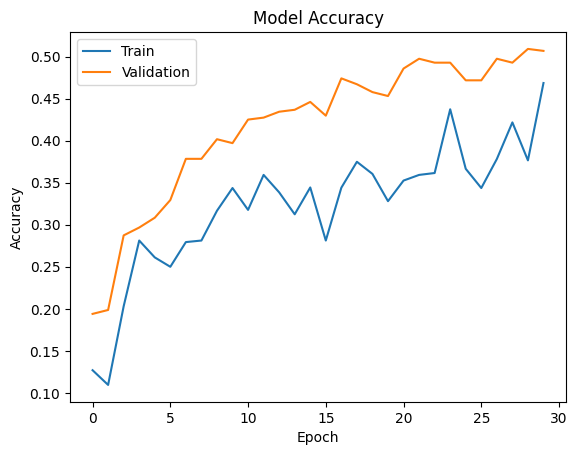

In [ ]:
plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- The model's accuracy is not good as evinced by the growing distance between the Train and Validation graphs.
- The model is overfitting

**Evaluate the model on test data**

In [ ]:
accuracy = model3.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 24s - 2s/step - accuracy: 0.4758 - loss: 1.5834


- The model's accuracy has dropped from 59% and 76% previously, to 45%

**Plotting the Confusion Matrix**

In [ ]:
y_pred=model3.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step


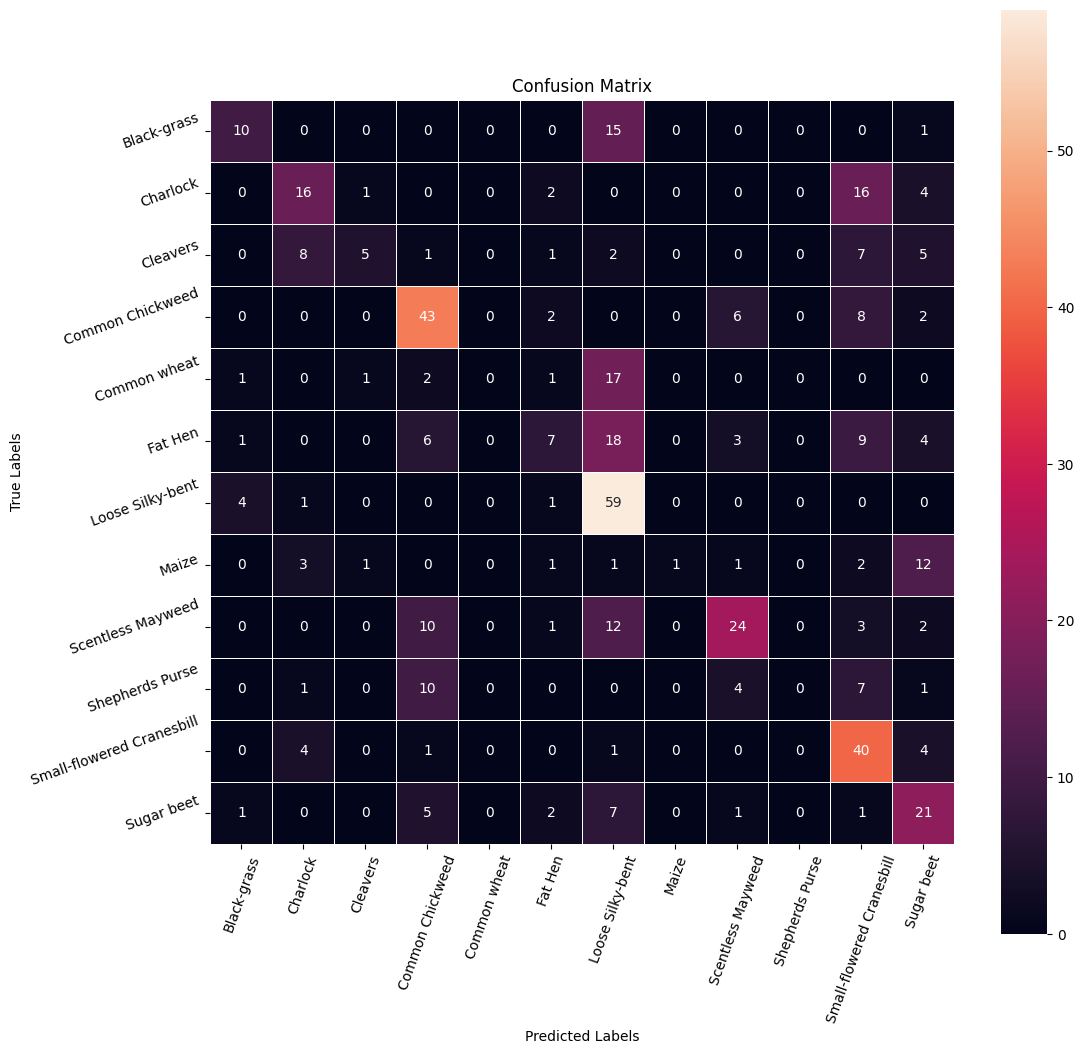

In [ ]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred, axis=1)
y_test_arg=np.argmax(y_test_encoded, axis=1)

# Plotting the Confusion Matrix using confusion_matrix() function which is also predefined in the Tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg )
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt='d',
    square=True,
    ax=ax
)

# Setting the labels to both the axes
ax.set_xlabel('Predicted Labels');ax.set_ylabel('True Labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=70)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

**Observations:**

- 5 classes are not predicted at all; _Black-grass_, _Cleavers_, _Common Wheat_, _Maize_ and _Shepherds Purse_
- The model classifies 2 classes fairly well; _Loose Silky-belt_ and _Common Chickweed_


**Plotting the Classification Report**

In [ ]:
# Plot the classification report
cr= classification_report(y_test_arg, y_pred_arg )
print(cr)

              precision    recall  f1-score   support

           0       0.59      0.38      0.47        26
           1       0.48      0.41      0.44        39
           2       0.62      0.17      0.27        29
           3       0.55      0.70      0.62        61
           4       0.00      0.00      0.00        22
           5       0.39      0.15      0.21        48
           6       0.45      0.91      0.60        65
           7       1.00      0.05      0.09        22
           8       0.62      0.46      0.53        52
           9       0.00      0.00      0.00        23
          10       0.43      0.80      0.56        50
          11       0.38      0.55      0.45        38

    accuracy                           0.48       475
   macro avg       0.46      0.38      0.35       475
weighted avg       0.47      0.48      0.42       475



## **Model 4 _ Spatial Dropout with Data Augmentation**

In [ ]:
# Clear backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Set data augmentation

train_datagen = ImageDataGenerator(
                                featurewise_center=True,                       # set input mean to 0 over the dataset
                                samplewise_center=True,                        # set each sample mean to 0
                                featurewise_std_normalization=False,            # divide inputs by std of the dataset
                                samplewise_std_normalization=False,             # divide each input by its std
                                rotation_range=20,                              # randomly rotate images in the range (degrees, 0 to 100)
                                zoom_range=0.1,                                 # randomly zoom image
                                width_shift_range=0.1,                          # randomly shift images horizontally (fraction of total width)
                                height_shift_range=0.1,                         # randomly shift images vertically (fraction of total height)
                                horizontal_flip=True,                            # randomly flip images
                                vertical_flip=True,                              # randomly flip images
                                fill_mode='nearest'
                                  )

In [ ]:
from tensorflow.keras.layers import SpatialDropout1D, SpatialDropout2D

In [ ]:
# Initialize a sequential model
model4 = Sequential()

# Adding first convolutional layer with 64 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of images
model4.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))

# Adding max pooling to reduce the output size of the first convolutional layer followed by Spatial Dropout
model4.add(MaxPooling2D((2, 2), padding='same'))
model4.add(SpatialDropout2D(0.4))

model4.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model4.add(MaxPooling2D((2, 2), padding='same'))
model4.add(BatchNormalization())

# model2.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# model2.add(MaxPooling2D((2, 2), padding='same'))

# flattening the output of the convolutional layer after max pooling to make it ready for creating dense connections
model4.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model4.add(Dense(16, activation='relu'))
model4.add(Dropout(0.3))

# Adding the output layer with 12 neurons and activation function as softmax since this is a multi-class classification
model4.add(Dense(12, activation='softmax'))

# Using Adam Optimizer
opt = Adam()

# Compile the model using the categorical_crossentropy loss function and accuracy metric
model4.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model4.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       262,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,340 (1.15 MB)

 Trainable params: 301,212 (1.15 MB)

 Non-trainable params: 128 (512.00 B)

**Fitting the model on train data**

In [ ]:
# Fit the model on train data with batch_size = 64 and epochs=30
#Epochs
epochs = 30
#Batch size
batch_size = 64


history_spd = model4.fit(train_datagen.flow(
    X_train_normalized, y_train_encoded,
    batch_size=batch_size,
    shuffle=False),
    epochs = epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_encoded),
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 926ms/step - accuracy: 0.1429 - loss: 2.5335 - val_accuracy: 0.1379 - val_loss: 2.4523
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2344 - loss: 2.2301 - val_accuracy: 0.1379 - val_loss: 2.4487
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 916ms/step - accuracy: 0.2626 - loss: 2.1402 - val_accuracy: 0.1472 - val_loss: 2.4037
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.2344 - loss: 2.0982 - val_accuracy: 0.1495 - val_loss: 2.4001
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 81s 929ms/step - accuracy: 0.3235 - loss: 1.9626 - val_accuracy: 0.1519 - val_loss: 2.3650
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3906 - loss: 1.6744 - val_accuracy: 0.1706 - val_loss: 2.3564
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 78s 905ms/step - accuracy: 0.3554 - loss: 1.8913 - val_accuracy: 0.3084 - val_loss: 2.2894
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4219 - loss: 1.5539 - val_accuracy: 0.

**Model Evaluation**

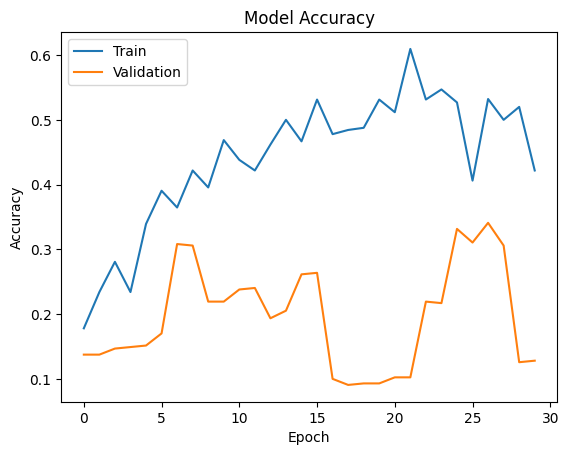

In [ ]:
plt.plot(history_spd.history['accuracy'])
plt.plot(history_spd.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- The model performs poorly given how divergent the Train and Validation graphs are
- The model is overfit

**Evaluate the model on test data**

In [ ]:
accuracy = model4.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 93ms/step - accuracy: 0.1411 - loss: 3.3556


- The accuracy's low at 32%

**Plotting the Confusion Matrix**

In [ ]:
y_pred=model4.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


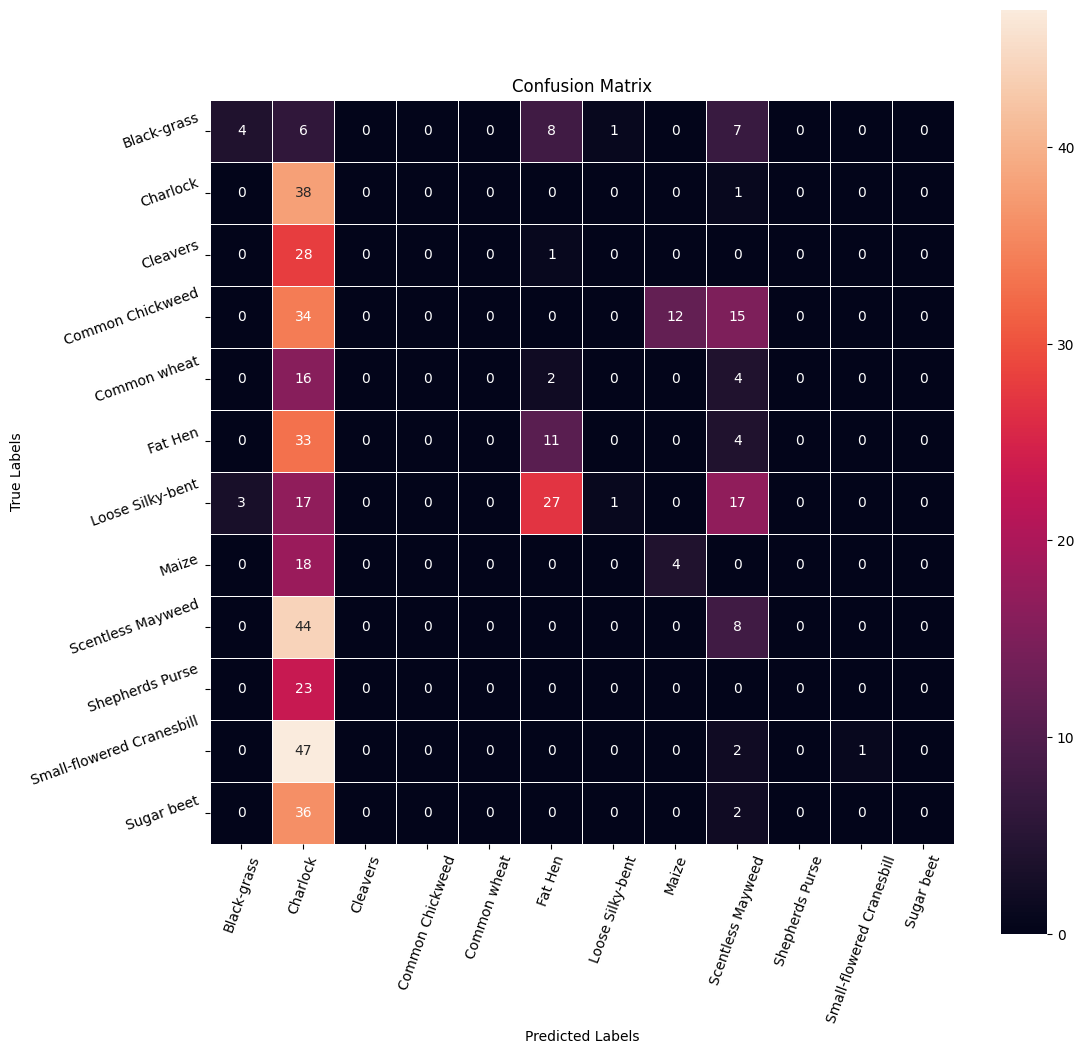

In [ ]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred, axis=1)
y_test_arg=np.argmax(y_test_encoded, axis=1)

# Plotting the Confusion Matrix using confusion_matrix() function which is also predefined in the Tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg )
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt='d',
    square=True,
    ax=ax
)

# Setting the labels to both the axes
ax.set_xlabel('Predicted Labels');ax.set_ylabel('True Labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=70)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)
plt.show()

- According to the confusion matrix and the accuracy curve, this model's performance is poorer than the previous models


**Plotting the Classification Report**

In [ ]:
# Plot the classification report
cr= classification_report(y_test_arg, y_pred_arg )
print(cr)

              precision    recall  f1-score   support

           0       0.57      0.15      0.24        26
           1       0.11      0.97      0.20        39
           2       0.00      0.00      0.00        29
           3       0.00      0.00      0.00        61
           4       0.00      0.00      0.00        22
           5       0.22      0.23      0.23        48
           6       0.50      0.02      0.03        65
           7       0.25      0.18      0.21        22
           8       0.13      0.15      0.14        52
           9       0.00      0.00      0.00        23
          10       1.00      0.02      0.04        50
          11       0.00      0.00      0.00        38

    accuracy                           0.14       475
   macro avg       0.23      0.14      0.09       475
weighted avg       0.26      0.14      0.09       475



##**Final Model**

- Out of the four models, Model 2 (Data Augmentation) achieved the best performance
- I select Model 2 to visualize the plant seedling predictions

### Visualizing the prediction

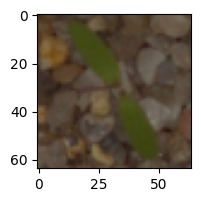

Predicted Label Fat Hen


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2, 2))
plt.imshow(X_test[2])
plt.show()

print('Predicted Label', enc.inverse_transform(y_test_encoded)[2])

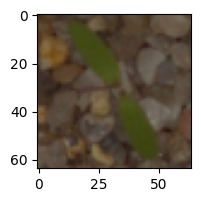

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Label ['Fat Hen']
True Label Fat Hen


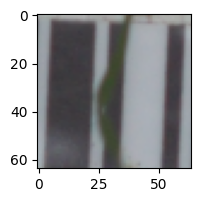

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Label ['Loose Silky-bent']
True Label Black-grass


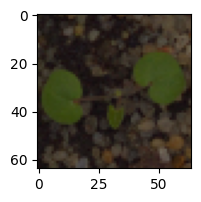

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Small-flowered Cranesbill


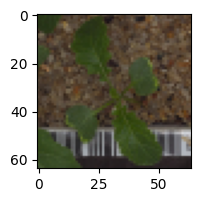

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Label ['Scentless Mayweed']
True Label Charlock


In [ ]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test[2])
plt.show()
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[2].reshape(1,64,64,3)))))   # Reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[2])                                               ## using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[33])
plt.show()
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[33].reshape(1,64,64,3)))))  # Reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[33])                                                ## using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[59])
plt.show()
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[59].reshape(1,64,64,3)))))  # Reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[59])                                                 ## using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test[36])
plt.show()
print('Predicted Label', enc.inverse_transform(model2.predict((X_test_normalized[36].reshape(1,64,64,3)))))  # Reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_encoded)[36])                                               ## using inverse_transform() to get the output label from the output vector


I built four CNN models and observed their performance through confusion matrices. Here are my insights and recommendations:

##**Actionable Insights**
- I found that Model 2 (Data Augmentation) was the best because it predicted most classes better than the other models.

- Data augmentation improved performance significantly: Model 2 achieved 76% test accuracy compared to 59% for the original CNN.

- The VGG16 model returned an accuracy of 45%.

- The transfer learning model did not produce better results than the ordinary CNNs.

##**Recommendations**
- I can improve the models by training with different filter sizes, varying the number of filters, adding hidden layers, and applying techniques like Batch Normalization.

- Training the models on the original image size of 128 x 128, instead of reducing to 64 x 64, could enhance performance.

- I plan to explore other transfer learning architectures to train the CNN models and improve classification.